# Maximum Entropy and the Exponential Family

### [Neil D. Lawrence](http://inverseprobability.com)

### 2026-11-10

**Abstract**: Jaynes’ maximum entropy principle, the exponential family
as the MaxEnt family, and the first synthesis of the three operational
readings of entropy. This is the intended answer to “how is entropy
understood today?” to be revised again after von Neumann entropy in week
8.

$$
$$

<!-- Do not edit this file locally. -->
<!-- Do not edit this file locally. -->
<!---->
<!-- Do not edit this file locally. -->
<!-- Do not edit this file locally. -->
<!-- The last names to be defined. Should be defined entirely in terms of macros from above-->
<!--

-->

Worksheet 2 is due at the start of this session. Quiz 2 occupies the
first ten minutes (MaxEnt, exponential family, Landauer).

## This Session

**Time plan (120 minutes)**

| Minutes | Block                                                                      |
|--------:|:---------------------------------------------------------------------------|
|    0–10 | Quiz 2 (Moodle); collect Worksheet 2                                       |
|   10–55 | Laplace $\to$ Jaynes; Lagrange; die and Gaussian                           |
|   55–65 | Break                                                                      |
|   65–95 | Exponential family; two-level $=$ Bernoulli; softmax; two-spin Hamiltonian |
|  95–110 | Legendre transform: $F=U-TS$ again; $H=A-\theta\cdot\eta$                  |
| 110–120 | LO7 synthesis; “how is entropy understood today?”                          |

## Maximum Entropy

## Lagrange Multipliers

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_maths/includes/lagrange-multipliers.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_maths/includes/lagrange-multipliers.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Many problems in physics, engineering and machine learning ask us to
optimise a function subject to constraints. For example, we free energy
minimisation, or maximising entropy while matching observed averages.[1]
Principal component analysis can be formulated as finding directions in
data of maximum variance. Each direction is constrained to be orthogonal
to the previous one. Lagrange multipliers turn these constrained
problems into unconstrained ones.

[1] Although because total energy is given by free energy plus
temperature-scaled entropy, these two optimisations are two sides of the
same coin.

## One Equality Constraint

If we want to find a stationary point of a function, $f(\mathbf{x})$,
and we know that another function $g(\mathbf{x}) = c$ is constrained
such that $g(\mathbf{x}) = c$ we introduce a *Lagrange multiplier*,
often denoted by $\lambda$ and form the *Lagrangian*, $$
\mathscr{L}(\mathbf{x}, \lambda) = f(\mathbf{x}) + \lambda\bigl(g(\mathbf{x}) - c\bigr).
$$ We are optimising with respect to $\mathbf{x}$ and the gradient of
the Lagrangian is given by $$
\nabla_{\mathbf{x}} \mathscr{L} = \nabla f + \lambda \nabla g,
$$ but we now also have the gradient of the Lagrangian with respect to
the Lagrange multiplier, $$
\frac{\partial \mathscr{L}}{\partial \lambda} = g(\mathbf{x}) - c.
$$ Think about what happens when we set both gradients to zero (as we
would do if we were looking for a stationary point of an unconstrained
function). The first equation is now $$
\nabla f + \lambda \nabla g = \mathbf{0}
$$ which tells us that $\nabla f$ is parallel to $\nabla g$, and
therefore the gradient of the objective, $\nabla f$, is perpendicular to
the constraint surface.

In [13]:
import mlai.plot as plot

In [14]:
plot.lagrange_parallel_vectors(diagrams='./physics/')

13

In [15]:
import notutils as nu
from ipywidgets import IntSlider

In [16]:
nu.display_plots('lagrange-parallel-vectors{sample:0>3}.svg',
                                          directory='./physics',
                                          sample=IntSlider(0, 0, 12, 1))

interactive(children=(IntSlider(value=0, description='sample', max=12), Output()), _dom_classes=('widget-inter…

<img src="https://mlatcl.github.io/iei/slides/diagrams/physics/lagrange-parallel-vectors012.svg" class="" width="70%" style="vertical-align:middle;">

Figure: <i>At stationarity, $\nabla f + \lambda\nabla g = \mathbf{0}$:
the objective gradient is balanced by the constraint gradient scaled by
$\lambda$ (here $\lambda = -\frac{1}{2}$ in the worked example).</i>

The second condition, $$
g(\mathbf{x}) - c = 0,
$$ just enforces the constraint itself ($g(\mathbf{x}) = c$).

Picture climbing a hill (maximise $f$) while staying on a path defined
by $g(\mathbf{x}) = c$. At the highest point reachable on the path, you
cannot move along the path and still increase $f$. That means $\nabla f$
points off the path, normal to the constraint surface. The multiplier
$\lambda$ measures how strongly the constraint must pull against the
unconstrained gradient.

## Several Equality Constraints

With multiple constraints $g_k(\mathbf{x}) = c_k$ for
$k = 1, \ldots, m$, introduce one multiplier $\lambda_k$ for each
constraint: $$
\mathscr{L}(\mathbf{x}, \boldsymbol{\lambda}) = f(\mathbf{x}) + \sum_{k=1}^m \lambda_k \bigl(g_k(\mathbf{x}) - c_k\bigr).
$$ Stationarity gives Each multiplier enforces one constraint; together
they specify how far the objective gradient is rotated onto the
intersection of the constraint surfaces.

## A Worked Example

The method is clearer on a small problem before we apply it to
probabilities. Minimise $$
f(x,y) = \frac{1}{2}(x^2 + y^2)
$$ subject to the linear constraint $x + y = 1$. Geometrically, we seek
the point on the line closest to the origin; physically, this is the
same pattern as minimising a quadratic energy or loss while a conserved
quantity remains fixed. The Lagrangian is $$
\mathscr{L}(x,y,\lambda) = \frac{1}{2}(x^2 + y^2) + \lambda(x + y - 1).
$$ Stationarity gives $x + \lambda = 0$, $y + \lambda = 0$, and
$x + y = 1$, hence $x = y = \frac{1}{2}$ and $\lambda = -\frac{1}{2}$.
The gradient of $f$ at the solution is $(1,1)$, parallel to the
constraint normal $(1,1)$ as required.

The same template appears in machine learning: minimise a squared error
or regulariser $\frac{1}{2}\|\mathbf{w}\|^2$ subject to a linear
prediction constraint $\mathbf{w}^\top \mathbf{x} = y$. The multiplier
$\lambda$ then plays the role of a Lagrange multiplier in ridge
regression and support-vector margins. We do not need that full story
here; the point is that one constraint adds one multiplier and reduces
the problem to solving linear stationarity conditions.

<!-- SNIPPET: _physics/includes/laplace-insufficient-reason.md-->

## Laplace and the Principle of Insufficient Reason

### Pierre-Simon Laplace

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_physics/includes/laplace-portrait.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_physics/includes/laplace-portrait.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

<img class="" src="https://mlatcl.github.io/iei/slides/diagrams/ml/Pierre-Simon_Laplace.png" style="width:30%; height:auto; display:block;">

Figure: <i>Pierre-Simon Laplace 1749-1827.</i>

In the *Philosophical Essay on Probabilities* (Laplace, 1814), Laplace
argues that probability is relative in part to our ignorance and in part
to our knowledge. When we know only that one of $n$ mutually exclusive
and exhaustive outcomes must occur, and nothing induces us to prefer one
over another, we should assign This is his *principle of insufficient
reason* (also called the principle of indifference). It is the
least-committal assignment consistent with the information we have:
namely, none beyond the list of possibilities and normalisation.

The same idea appears in the passage we called Laplace’s gremlin in week
1: if several cases are equally possible and nothing favours one, we
cannot announce any particular outcome with certainty, and the natural
probability weights them equally.

In [17]:
import notutils as nu
nu.display_google_book(id='1YQPAAAAQAAJ', page='PA16')

Laplace wondered, what is the probability that the sun will rise
tomorrow? We’ve seen it rise every day so is it 100%?

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import mlai

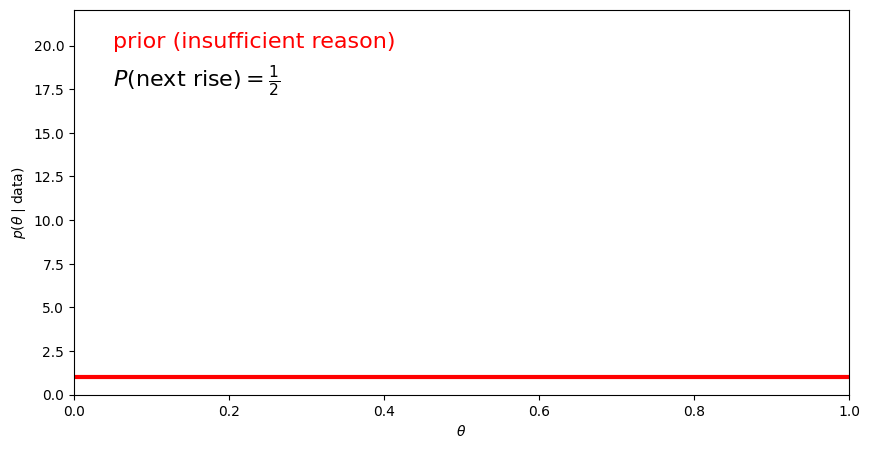

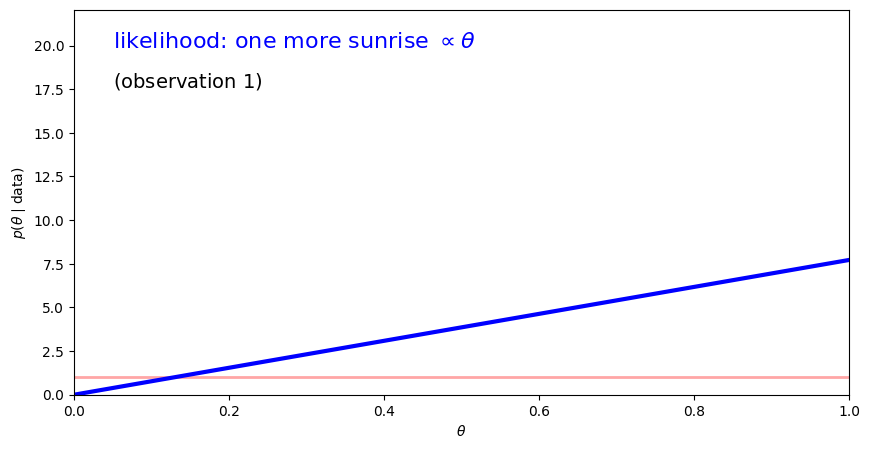

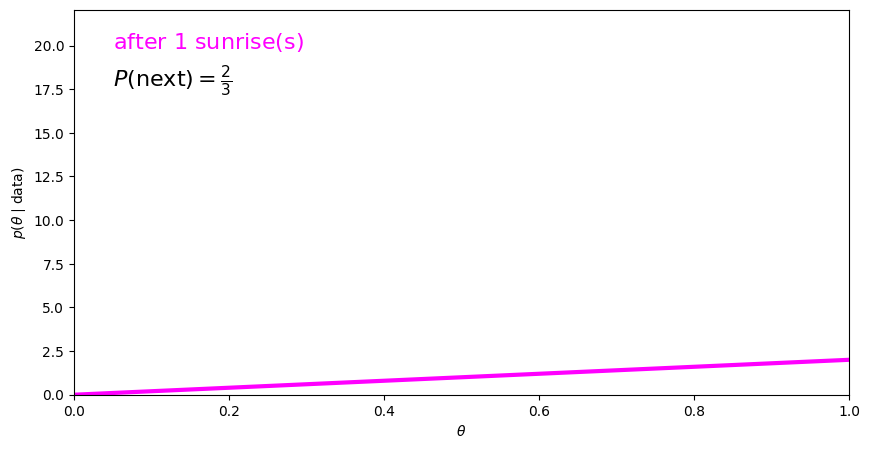

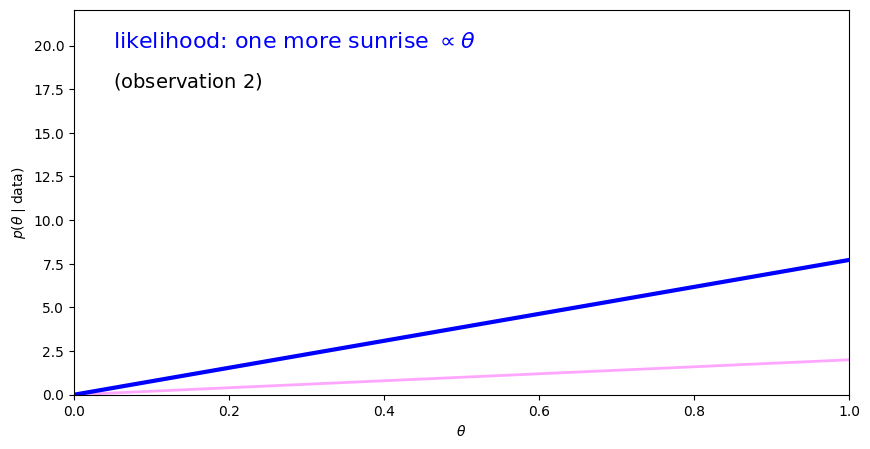

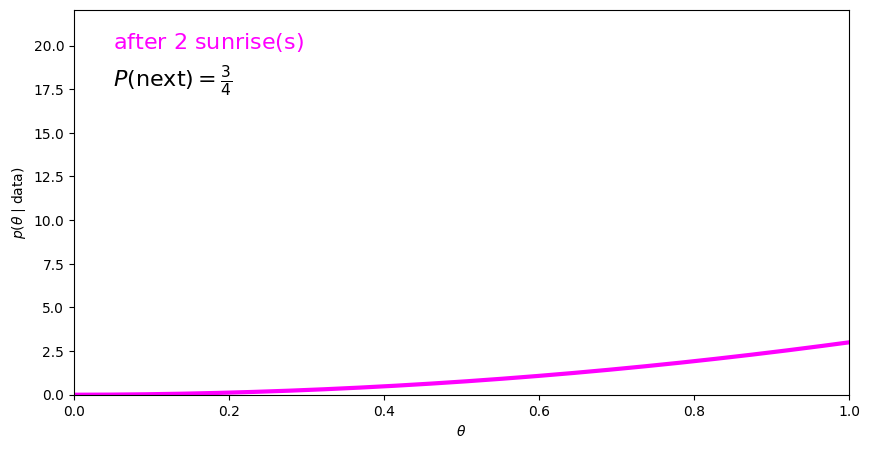

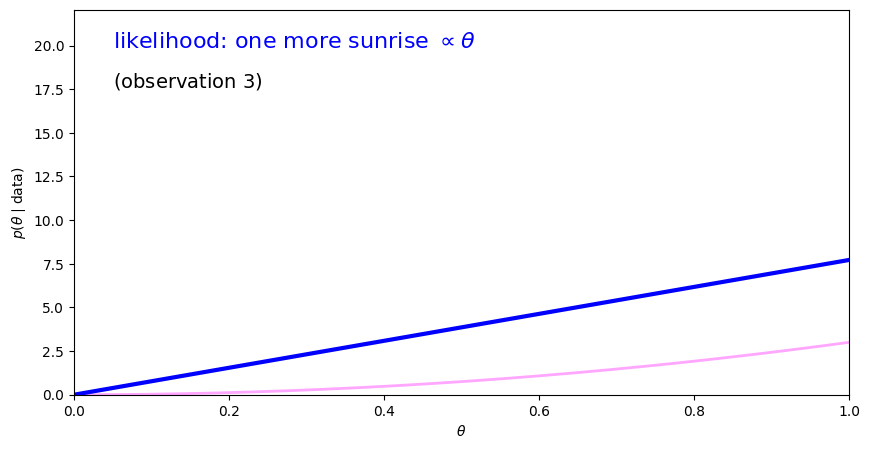

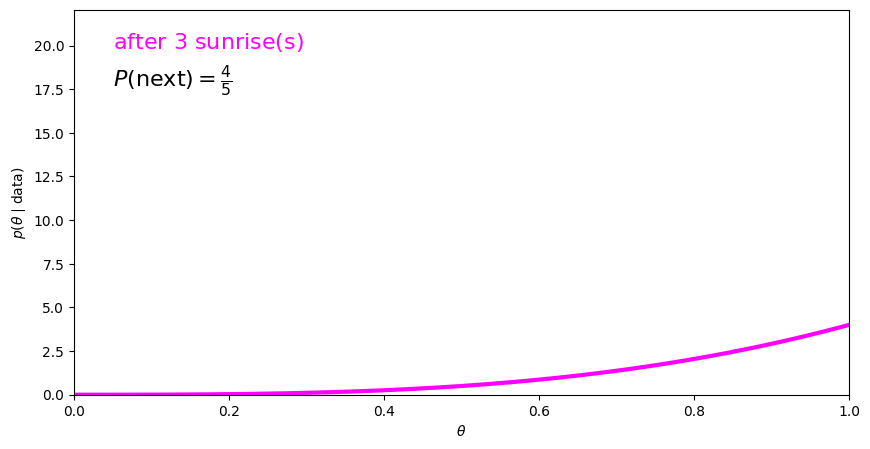

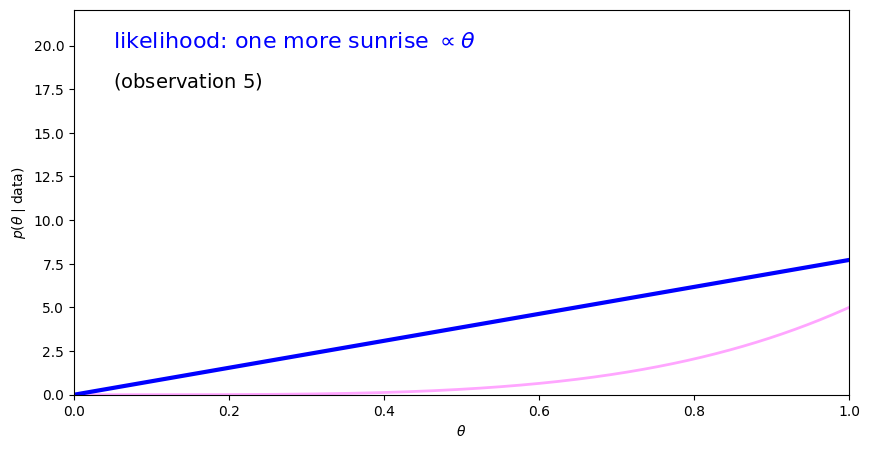

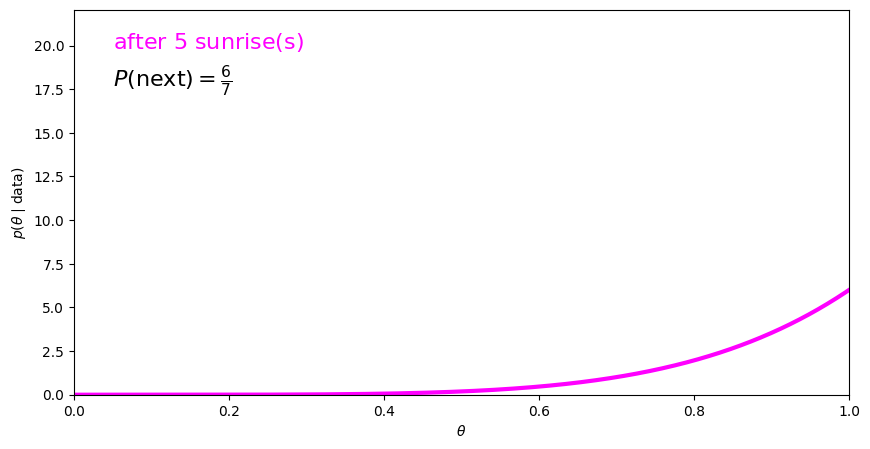

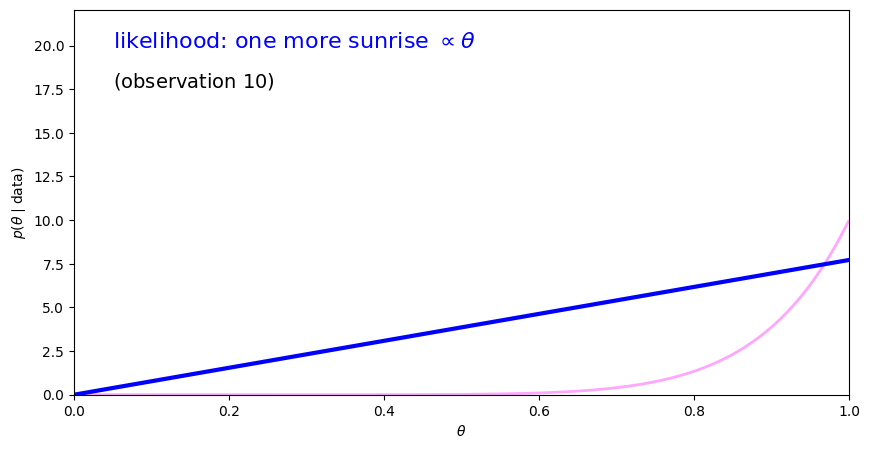

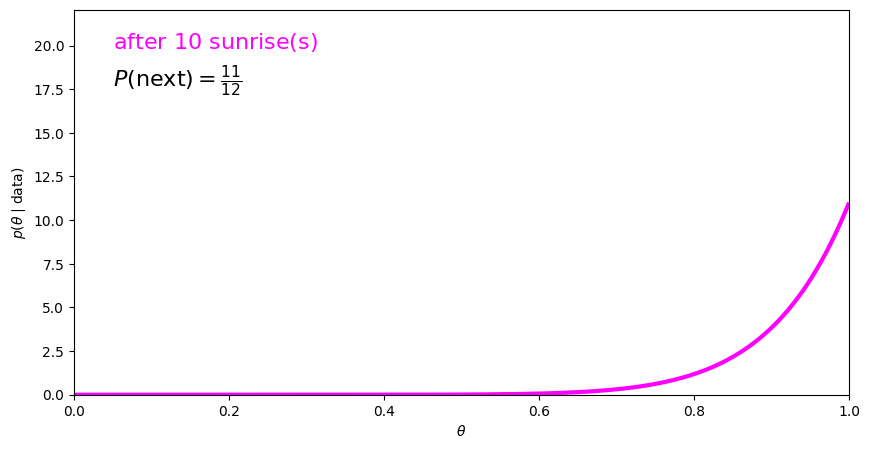

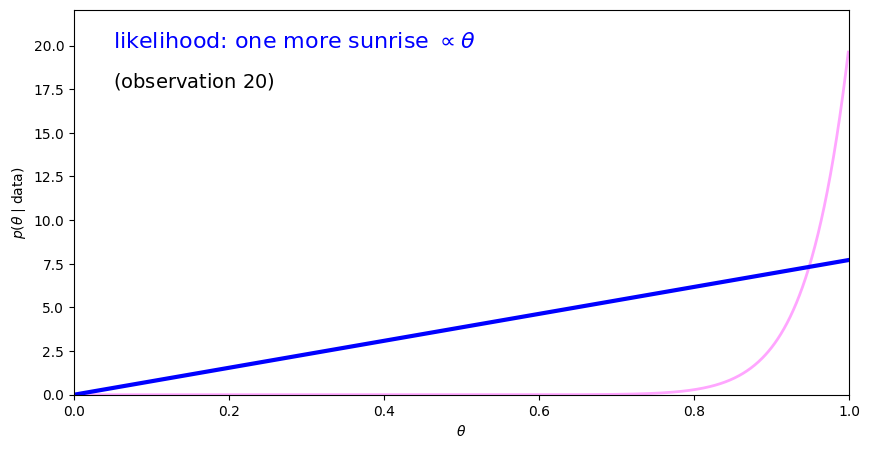

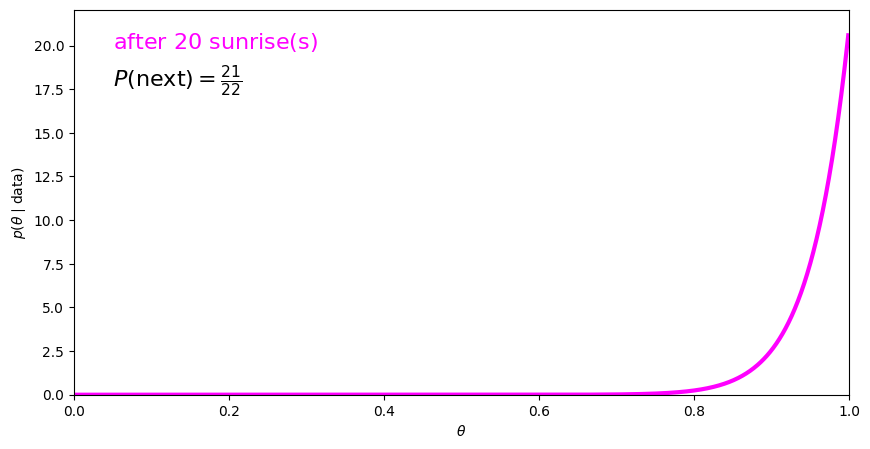

In [19]:
# Successive sunrises only: after n rises, belief ∝ θ^n (modern Beta(n+1,1)).
# Frames alternate prior/belief → likelihood of one more rise → updated posterior.
theta = np.linspace(0.001, 0.999, 1000)
steps = [1, 2, 3, 5, 10, 20]  # number of observed sunrises after each update
ymax = (steps[-1] + 1) * 1.05
diagrams = './ml'
frame = 0

def _axes():
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, ymax)
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'$p(\theta\mid\mathrm{data})$')
    return fig, ax

def _belief(n):
    # n observed sunrises → density (n+1) θ^n on [0,1]
    return (n + 1) * theta**n

fig, ax = _axes()
ax.plot(theta, _belief(0), color=[1, 0, 0], linewidth=3)
ax.text(0.05, ymax * 0.9, r'prior (insufficient reason)', fontsize=16, color=[1, 0, 0])
ax.text(0.05, ymax * 0.8, r'$P(\mathrm{next\ rise})=\frac{1}{2}$', fontsize=16)
frame += 1
mlai.write_figure(f'laplace-succession{frame:03d}.svg', directory=diagrams)

for n in steps:
    # Likelihood of one more sunrise: ∝ θ (always a success)
    fig, ax = _axes()
    if n == 1:
        ax.plot(theta, _belief(0), color=[1, 0, 0], linewidth=2, alpha=0.35)
    else:
        ax.plot(theta, _belief(n - 1), color=[1, 0, 1], linewidth=2, alpha=0.35)
    ax.plot(theta, theta * (ymax * 0.35), color=[0, 0, 1], linewidth=3)  # shape ∝ θ
    ax.text(0.05, ymax * 0.9, r'likelihood: one more sunrise $\propto\theta$', fontsize=16, color=[0, 0, 1])
    ax.text(0.05, ymax * 0.8, r'(observation $%d$)' % n, fontsize=14)
    frame += 1
    mlai.write_figure(f'laplace-succession{frame:03d}.svg', directory=diagrams)

    # Posterior after n sunrises
    fig, ax = _axes()
    ax.plot(theta, _belief(n), color=[1, 0, 1], linewidth=3)
    ax.text(0.05, ymax * 0.9, r'after $%d$ sunrise(s)' % n, fontsize=16, color=[1, 0, 1])
    ax.text(0.05, ymax * 0.8,
            r'$P(\mathrm{next})=\frac{%d}{%d}$' % (n + 1, n + 2),
            fontsize=16)
    frame += 1
    mlai.write_figure(f'laplace-succession{frame:03d}.svg', directory=diagrams)

n_frames = frame

<img src="https://mlatcl.github.io/iei/slides/diagrams/ml/laplace-succession013.svg" class="" width="70%" style="vertical-align:middle;">

Figure: <i>Successive sunrises only. Each observation multiplies the
current belief by a likelihood $\propto\theta$; after $n$ rises the
density is $(n+1)\theta^n$ and the predictive probability is
$(n+1)/(n+2)$. The mass piles up toward $\theta=1$ as $n$ grows.</i>

Laplace applies insufficient reason not only to discrete outcomes, but
to an unknown daily rate $\theta\in[0,1]$. Knowing nothing about
$\theta$, he places a uniform prior $p(\theta)=1$ on the unit interval.
Every recorded day is a *success*: the sun rose. After $n$ independent
rises the likelihood is $\theta^n$, so and the probability of one
further rise is the posterior mean This is *Laplace’s rule of
succession* (the same “$+1$, $+2$” that later appears as Laplace
smoothing). In modern notation the posterior is $\mathrm{Beta}(n+1,1)$;
after each new sunrise it becomes $\mathrm{Beta}(n+2,1)$, more sharply
peaked at $\theta=1$, while the predictive odds move from $1{:}1$ toward
certainty without ever quite reaching it.

Laplace did not have the Beta distribution by name, and he did not need
the Laplace approximation for this result. In the 1774 memoir on inverse
probability he evaluates the normalising integrals exactly — what we now
write as $\int_0^1 \theta^{n}\,\mathrm{d}\theta = 1/(n+1)$ — via what he
called Euler’s series. The Beta language is modern packaging of that
calculation. The *Laplace approximation* (a local Gaussian expansion of
an integrand about its mode) is a different tool, also named after him;
it is not how the rule of succession was obtained.

In the Essay he takes the oldest historical epoch as five thousand
years, or $n=1{,}826{,}213$ days of recorded sunrise, and concludes that
— *on this information alone* — the odds on tomorrow’s sunrise are
$1{,}826{,}214$ to one. He then adds, in the next sentence, that for
anyone who recognises the astronomical regularity of days and seasons
the probability is *incomparably greater*. The sunrise calculation is a
demonstration of the rule under deliberate ignorance of mechanism, not
Laplace’s estimate of whether the sun will rise.

So the preliminary example already shows the pattern we need:
insufficient reason supplies the prior of ignorance; each success
updates it and peels a little more mass away from small $\theta$; the
predictive probability is not the raw frequency $n/n=1$.

The principle of insufficient reason, and the rule of succession built
from it, answer the case where our information is a list of
possibilities and (optionally) raw counts. As soon as we know more — a
mean face value on a die, a mean energy, a variance — equal weights, or
a uniform prior on a single rate, may fail to encode that information.
Jaynes’ maximum entropy principle extends Laplace’s idea: among all
distributions that match the stated constraints, choose the one that
maximises Shannon entropy $H(p)=-\sum_i p_i\log p_i$. That choice is
maximally noncommittal with respect to everything else.

With only the normalisation constraint $\sum_i p_i=1$, MaxEnt recovers
Laplace’s uniform assignment $p_i=1/n$. With an additional mean-energy
constraint, the same calculation yields Boltzmann weights. With mean and
variance, it yields a Gaussian. The exponential family is therefore the
family of distributions that generalise insufficient reason from “we
know nothing” (or “we know only these counts”) to “we know these moments
and nothing more.”

Critiques of bare indifference (Bertrand’s paradox and related
reparameterisation puzzles) motivate the need for an explicit state
space and explicit constraints — which is exactly what the MaxEnt
formalism supplies. We will not pursue those paradoxes here; the
operational fix is to state what is held fixed before maximising $H$.
Laplace’s own sunrise caveat makes the same point in plain language:
once you know the mechanism, you no longer pretend to know only the
counts.

<!-- /SNIPPET: _physics/includes/laplace-insufficient-reason.md-->

## Jaynes and Maximum Entropy

<img class="" src="https://mlatcl.github.io/iei/slides/diagrams/physics/e-t-jaynes.jpg" style="width:40%; height:auto; display:block;">

Figure: <i>Ed Jaynes who developed the maximum entropy principle</i>

## Maximum Entropy Motivation

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_physics/includes/maximum-entropy-motivation.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_physics/includes/maximum-entropy-motivation.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Ed Jaynes (Jaynes, 1957), proposed a foundation for statistical
mechanics based on information theory. Jaynes recast that the problem of
assigning probabilities in statistical mechanics as a problem of
inference with incomplete information.

A central problem in statistical mechanics is assigning initial
probabilities when our knowledge is incomplete. The canonical example is
if we know only the average energy of a system, what probability
distribution should we use? Jaynes argued that we should use the
distribution that maximises entropy subject to the constraints of our
knowledge.

Jaynes illustrated the approach with a simple example. If a die has been
tossed many times, with an average result of 4.5 rather than the
expected 3.5 for a fair die. What probability assignment $P_n$
($n=1,2,...,6$) should we make for the next toss?

We need to satisfy two constraints

Many distributions could satisfy these constraints, but which one makes
the fewest unwarranted assumptions? Jaynes argued that we should choose
the distribution that is maximally noncommittal with respect to missing
information - the one that maximises the entropy, This principle leads
to the exponential family of distributions, which in statistical
mechanics gives us the canonical ensemble and other familiar
distributions.

## Die Roll Simulation

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_physics/includes/dieroll.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_physics/includes/dieroll.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

This simulation illustrates the maximum entropy principle through
Jaynes’ dice example (Jaynes, 1957). A fair die has expected outcome
3.5; the *Jaynes example* asks: if we know only that the average outcome
is 4.5, what probability distribution $P_n$ over the six faces should we
assign?

The answer is the maximum-entropy distribution subject to the constraint
$\sum_{n=1}^6 n P_n = 4.5$, which belongs to the exponential family:
where $\lambda > 0$ is chosen so the mean constraint is satisfied. This
avoids any unwarranted assumption beyond the available data.

<div style="width:100%;max-width:780px;font-family:sans-serif;font-size:0.82em">
<div style="display:flex;gap:16px;flex-wrap:wrap;align-items:flex-start">
<div style="display:flex;flex-direction:column;align-items:center;gap:6px;min-width:160px">
<canvas id="dieroll-die" width="150" height="150" style="display:block;cursor:pointer">
</canvas>

click die or button to roll

<button id="dieroll-roll">

Roll

</button>
<button id="dieroll-roll100">

Roll ×100

</button>

Rolls: <strong id="dieroll-count">0</strong><br> Sample mean: <span
id="dieroll-mean">—</span><br> H(p): <span id="dieroll-entropy"
style="color:#2ecc71">—</span>

<button id="dieroll-reset">

Reset history

</button>
<hr style="width:100%;border:none;border-top:1px solid #444;margin:4px 0">

<button id="dieroll-uniform">

Uniform (mean 3.5)

</button>
<button id="dieroll-jaynes">

Jaynes: mean 4.5

</button>
<button id="dieroll-simple">

Simple 50/50: mean 4.5

</button>
<button id="dieroll-low">

Low-biased: mean 2

</button>

</div>

<canvas id="dieroll-hist" width="500" height="210" style="display:block;width:100%;height:auto;border-radius:6px">
</canvas>

Outcome weights (auto-normalised to probabilities)

</div>
</div>
<script src="../scripts//dieroll/dieroll.js"></script>

Figure: <i>Interactive die-roll simulation. Click the die or press Roll
to sample from the configured distribution. The histogram shows
empirical relative frequencies (coloured bars) overlaid on the
theoretical probabilities (dashed outlines). Use the sliders to set
arbitrary outcome weights, or click a preset to load the uniform
distribution (mean 3.5), the Jaynes maximum-entropy distribution (mean
4.5), the simple 50/50 distribution (faces 4 and 5 equally, mean 4.5
with minimal entropy), or a low-biased distribution (mean 2).</i>

## The General Maximum-Entropy Formalism

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_physics/includes/maximum-entropy-formalism.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_physics/includes/maximum-entropy-formalism.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

For a more general case, suppose a quantity $x$ can take values
$(x_1, x_2, \ldots, x_n)$ and we know the average values of several
functions $f_k(x)$. The problem is to find the probability assignment
$p_i = p(x_i)$ that satisfies and maximises the entropy
$S_I = -\sum_{i=1}^n p_i \log p_i$.

Using Lagrange multipliers, the solution is the generalised canonical
distribution, where $Z(\lambda_1,\ldots,\lambda_m)$ is the partition
function, The Lagrange multipliers $\lambda_k$ are determined by the
constraints, The maximum attainable entropy is

$$
p_i = \frac{\exp(-\lambda_1 f_1(x_i) - \ldots - \lambda_m f_m(x_i))}{Z(\lambda_1,\ldots,\lambda_m)}
$$ $$
Z(\ldots) = \sum_{i=1}^n \exp(-\lambda_1 f_1(x_i) - \ldots - \lambda_m f_m(x_i))
$$ $$
\langle f_k \rangle = -\frac{\partial}{\partial \lambda_k}\log Z(\lambda_1,\ldots,\lambda_m) \quad k=1,2,\ldots,m.
$$

<!-- SNIPPET: _physics/includes/maxent-canonical-gaussian.md -->
Maximum entropy is the week’s pair in one move: entropy forbids assuming
more structure than the constraints; probability is the recipe. One
mean-energy constraint gives Boltzmann weights; mean and variance give
the Gaussian. The Lagrange multiplier on energy is coldness $\beta$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import mlai

In [ ]:
faces = np.arange(1, 7)

def maxent_die(target_mean):
    def objective(p):
        p = np.clip(p, 1e-12, 1)
        p = p / p.sum()
        return np.sum(p * np.log(p))
    cons = (
        {'type': 'eq', 'fun': lambda p: np.sum(p) - 1},
        {'type': 'eq', 'fun': lambda p: np.dot(p, faces) - target_mean},
    )
    p0 = np.ones(6) / 6
    res = minimize(objective, p0, constraints=cons)
    return res.x

p_jaynes = maxent_die(4.5)
p_unif = np.ones(6) / 6
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(faces - 0.2, p_unif, width=0.35, label='uniform')
ax.bar(faces + 0.2, p_jaynes, width=0.35, label='MaxEnt mean=4.5')
ax.set_xlabel('face')
ax.set_ylabel('probability')
ax.legend()
mlai.write_figure('jaynes-die-maxent.svg', directory='./ml')

<img src="https://mlatcl.github.io/iei/slides/diagrams/ml/jaynes-die-maxent.svg" class="" width="75%" style="vertical-align:middle;">

Figure: <i>Jaynes’ die: MaxEnt subject to mean 4.5 versus the uniform
distribution.</i>

<!-- /SNIPPET: _physics/includes/maxent-canonical-gaussian.md -->

## The Exponential Family

## Exponential Families

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_physics/includes/exponential-families.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_physics/includes/exponential-families.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

The exponential family is a class of probability distributions that
plays a central role in information theory and statistical mechanics.
For our purposes, these distributions have particularly elegant
properties when we work with their *natural parameters*.

### Definition

A probability distribution belongs to the exponential family if it can
be written in the form $$
p(\mathbf{x} | \boldsymbol{\theta}) = \exp\left(\boldsymbol{\theta}^\top T(\mathbf{x}) - \mathcal{A}(\boldsymbol{\theta})\right) h(\mathbf{x}),
$$ where - $\boldsymbol{\theta} \in \mathbb{R}^d$ are the **natural
parameters** - $T(\mathbf{x})$ are the **sufficient statistics**  
- $\mathcal{A}(\boldsymbol{\theta})$ is the **log partition function**
(ensures normalization) - $h(\mathbf{x})$ is the **base measure** (often
constant)

The natural parameters are called “natural” because they appear linearly
in the exponent. This parametrization has special geometric properties
that make information-theoretic calculations particularly clean. As
we’ll see, working with these connections makes the connections between
probability theory and geometry particularly clean.

### The Log Partition Function as Cumulant Generator

The setup of the exponential family ensures that the log partition
function operates as a cumulant generating function. We denote it by
$\mathcal{A}(\boldsymbol{\theta})$ and it ensures the distribution is
normalised. $$
\mathcal{A}(\boldsymbol{\theta}) = \log \int \exp\left(\boldsymbol{\theta}^\top T(\mathbf{x})\right) h(\mathbf{x}) \, d\mathbf{x}.
$$ But $\mathcal{A}$’s role as cumulant generating function also means
that we can compute the distributions cumulants through taking its
derivatives.

$$
\mathcal{A}(\boldsymbol{\theta}) = \log \int \exp\left(\boldsymbol{\theta}^\top T(\mathbf{x})\right) h(\mathbf{x}) \, d\mathbf{x}
$$}

The derivatives of $\mathcal{A}$ with respect to $\boldsymbol{\theta}$
give us the cumulants as follows. - **First derivative** (first
cumulant):
$\nabla \mathcal{A}(\boldsymbol{\theta}) = \mathbb{E}[T(\mathbf{x})]$
(the mean) - **Second derivative** (second cumulant):
$\nabla^2 \mathcal{A}(\boldsymbol{\theta}) = \mathrm{Cov}[T(\mathbf{x})]$
(the covariance) - **Higher derivatives**: Third and higher cumulants
(skewness, kurtosis, etc.)

### Connection to Fisher Information

For an exponential family, the second derivative of the log partition
function has a special meaning. It is the **Fisher information matrix**:
$$
G(\boldsymbol{\theta}) = \nabla^2 \mathcal{A}(\boldsymbol{\theta}) = \mathrm{Cov}_{\boldsymbol{\theta}}[T(\mathbf{x})].
$$ R.A. Fisher introduced this quantity in the context of statistical
estimation. Through the Cramér-Rao bound, Fisher information tells us
how accurately we can estimate parameters from data, higher Fisher
information means better estimation is possible.

The Fisher information is both the Hessian of the log partition function
*and* the covariance of the sufficient statistics. This dual role arises
from the log partition function being the cumulant generating function.
As we’ll see in the next section, the Fisher information matrix also
defines the geometry of the information space.

### Entropy in Natural Coordinates

The joint entropy of an exponential family distribution has a
straightforward form in natural coordinates, $$
H(\boldsymbol{\theta}) = -\mathbb{E}_{\boldsymbol{\theta}}[\log p(\mathbf{x}|\boldsymbol{\theta})] = \mathcal{A}(\boldsymbol{\theta}) - \boldsymbol{\theta}^\top \nabla \mathcal{A}(\boldsymbol{\theta}) - \mathbb{E}[\log h(\mathbf{x})].
$$ When the base measure $h(\mathbf{x})$ is constant (or when we measure
entropy relative to it), this simplifies to $$
H(\boldsymbol{\theta}) = \mathcal{A}(\boldsymbol{\theta}) - \boldsymbol{\theta}^\top \boldsymbol{\mu},
$$ where $\boldsymbol{\mu} = \nabla \mathcal{A}(\boldsymbol{\theta})$ is
the mean of the sufficient statistics.

Now we see the utilty of representing through natural parameers, when we
take the gradient of entropy with respect to the natural parameters,
many terms cancel, $$
\nabla_{\boldsymbol{\theta}} H = \nabla \mathcal{A}(\boldsymbol{\theta}) - \left(\boldsymbol{\theta}^\top \nabla^2 \mathcal{A} + \nabla \mathcal{A}\right) = -\boldsymbol{\theta}^\top \nabla^2 \mathcal{A} = -G(\boldsymbol{\theta})\boldsymbol{\theta}.
$$ This simple form for the entropy gradient equals negative Fisher
information times natural parameters.

## Example: Multivariate Gaussian

Let’s make this concrete with the multivariate Gaussian distribution. A
Gaussian with mean $\boldsymbol{\mu}$ and covariance $\Sigma$ can be
written as: $$
p(\mathbf{x}) = \frac{1}{(2\pi)^{d/2}|\Sigma|^{1/2}} \exp\left(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top\Sigma^{-1}(\mathbf{x}-\boldsymbol{\mu})\right).
$$ To put this in exponential family form, we need to identify the
natural parameters and sufficient statistics.

### Gaussian in Exponential Family Form

After expanding the quadratic form and collecting terms, the Gaussian
becomes: $$
p(\mathbf{x}) = \exp\left(\boldsymbol{\theta}^\top T(\mathbf{x}) - \mathcal{A}(\boldsymbol{\theta})\right) \cdot \frac{1}{(2\pi)^{d/2}},
$$ where: - Natural parameters:
$\boldsymbol{\theta} = \Sigma^{-1}\boldsymbol{\mu}$ (precision-weighted
mean) - Sufficient statistics: $T(\mathbf{x}) = \mathbf{x}$ (the data
itself) - Log partition function:
$\mathcal{A}(\boldsymbol{\theta}) = \frac{1}{2}\boldsymbol{\theta}^\top\Sigma\boldsymbol{\theta} + \frac{1}{2}\log|\Sigma|$

For the Gaussian, we can compute the Fisher information matrix directly:
$$
G(\boldsymbol{\theta}) = \nabla^2 \mathcal{A}(\boldsymbol{\theta}) = \Sigma.
$$ As expected, because the log partition is the covariance matrix.
Equivalently, $G^{-1} = \Sigma^{-1}$ is the precision matrix.

This reveals the intuition behind Fisher’s original concept: - Low
variance (high precision) → high Fisher information → parameters easier
to estimate (tighter Cramér-Rao bound) - High variance (low precision) →
low Fisher information → parameters harder to estimate (looser bound)

## Example: Categorical Distribution

Consider a categorical distribution over $K$ outcomes with probabilities
$\{\pi_1, \ldots, \pi_K\}$ where $\sum_k \pi_k = 1$. We represent an
outcome as a one-hot vector $\mathbf{x} \in \{0,1\}^K$ where exactly one
component is 1.

### Categorical in Exponential Family Form

The categorical distribution is: $$
p(\mathbf{x}) = \prod_{k=1}^K \pi_k^{x_k} = \exp\left(\sum_{k=1}^K x_k \log \pi_k\right).
$$ In exponential family form (using $K-1$ natural parameters due to the
sum-to-one constraint): - Natural parameters:
$\boldsymbol{\theta} = (\log \pi_1, \ldots, \log \pi_{K-1})$ (log
probabilities) - Sufficient statistics:
$T(\mathbf{x}) = (x_1, \ldots, x_{K-1})$ (one-hot encoding) - Log
partition function:
$\mathcal{A}(\boldsymbol{\theta}) = \log\left(\sum_{k=1}^{K-1} e^{\theta_k} + 1\right)$
(log-sum-exp)

The Fisher information matrix for the categorical distribution is: $$
G_{ij}(\boldsymbol{\theta}) = \begin{cases}
\pi_i(1-\pi_i) & \text{if } i=j \\
-\pi_i\pi_j & \text{if } i \neq j
\end{cases}
$$ This matrix encodes how “information” is distributed across
categories. When one category dominates ($\pi_i \approx 1$), the Fisher
information about other categories becomes small—it’s hard to learn
about rare events!

## Why Exponential Families Matter

Exponential families are not just mathematically convenient, they emerge
naturally from underlying principles:

1.  **Maximum Entropy**: Given constraints on the moments of a
    distribution, the maximum entropy distribution is in the exponential
    family (Jaynes, 1957).

2.  **Information Geometry**: The natural parameters define a coordinate
    system on the manifold of probability distributions where the Fisher
    information acts as a Riemannian metric (Amari, 2016).

3.  **Sufficient Statistics**: The sufficient statistics $T(\mathbf{x})$
    capture all the information in the data needed to estimate
    $\boldsymbol{\theta}$, nothing is lost by summarizing data through
    $T$.

4.  **Computational Tractability**: Many operations (computing
    gradients, conjugate priors, message passing) have closed-form
    solutions.

For the inaccessible game, exponential families provide the setting
where information dynamics have their cleanest mathematical form.

## Looking Ahead

We’ll see that the form
$\nabla H = -G(\boldsymbol{\theta})\boldsymbol{\theta}$ is crucial for
deriving the dynamics of the inaccessible game. The natural parameters
will be our coordinates, the Fisher information will be our “information
topography,” and entropy gradients will drive the system’s evolution.

$p(x\mid\theta)=\exp(\theta\cdot T(x)-A(\theta))$. Canonical, Gaussian,
and Bernoulli belong because each is MaxEnt for its moments. Softmax is
the same calculation with a feature map. The two-spin example is the
first sufficient statistic that is a product.

## Softmax is MaxEnt with Features

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/softmax-as-maxent.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/softmax-as-maxent.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

The two-level system from week 1 and the Bernoulli are the same
exponential family. Occupancy of the excited state is a bit. The natural
parameter is $\theta = -\beta\varepsilon$ if you are reading a
paramagnet, and $\theta = \log\frac{\pi}{1-\pi}$ if you are reading a
coin. The log-partition $A(\theta)=\log(1+e^{\theta})$ is binary
entropy’s conjugate in either language. That is the unary case of LO6,
already on the board.

The die constrained the mean of a single coordinate. A classifier
constrains the mean of a *feature* of the pair $(x,y)$. Write
$T(x,y)=f(x,y)$ for a vector of functions you have chosen — a bias, the
coordinates of $x$, an indicator that a word occurs, anything you can
compute. MaxEnt subject to $$
\mathbb{E}_{p(y\mid x)\,p_{\mathrm{data}}(x)}[f(x,y)] = \mathbb{E}_{p_{\mathrm{data}}}[f(x,y)]
$$ is the same Lagrange problem as the die. The solution is $$
p(y\mid x) = \exp\bigl(\theta\cdot f(x,y) - A(\theta;x)\bigr),
$$ with $A(\theta;x)=\log\sum_{y'}\exp(\theta\cdot f(x,y'))$ the
log-sum-exp over labels. That is softmax. Logistic regression is the
two-class case, $f(x,y)=y\,(1,x)$ for $y\in\{0,1\}$.

MacKay’s Exercises 22.12–22.13 record the identification:
maximum-likelihood fitting of an exponential family matches the moments
of $T$, and MaxEnt with those moments produces the same family (MacKay,
2003). The classifier does not care which story you tell.

Berger et al. (1996) is the natural-language version of this
calculation. They constrain binary features of the pair $(x,y)$ — a word
in a window, a part of speech, a class — and recover $$
p(y\mid x)=\exp\bigl(\lambda\cdot f(x,y)-A(\lambda;x)\bigr).
$$ They prove the dual: the MaxEnt distribution in that constrained set
is the exponential model of maximum likelihood on the sample. The
algorithm is generalized iterative scaling, which is moment matching.

The results are translation decisions in IBM’s Candide system, trained
on the Canadian Hansard. For French phrases — stays word-for-word, swaps
— a never-swap baseline is 70.2% accurate on 71,555 held-out cases. A
MaxEnt model grown to 358 features reaches 80.4%. They also grew models
for the French rendering of English and , and for finding rift points at
which a French sentence can be split without breaking an alignment.

MacKay then declines to use MaxEnt as a method of *inference* — the
loaded die, he says, is a job for Bayes. Hold that tension for the
synthesis. The object on this slide is not in dispute. It is an
exponential family whose sufficient statistic is a feature map.

## Two Spins, One Coupling

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_physics/includes/two-spin-maxent.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_physics/includes/two-spin-maxent.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Every MaxEnt example so far constrains a function of one variable: a
face, an energy, a bit, a feature of a labelled pair. The next legal
constraint is a *product*. Take two Ising spins $s_1,s_2\in\{+1,-1\}$
and prescribe the two magnetisations and the correlation, Four states,
three moment constraints, plus normalisation. The sufficient statistic
is $T(s)=(s_1,s_2,s_1 s_2)$. MaxEnt returns the two-spin Ising model
(Ising, 1925), $$
p(s_1,s_2) = \exp\bigl(h_1 s_1 + h_2 s_2 + J s_1 s_2 - A(h,J)\bigr).
$$ The Lagrange multiplier on the correlation *is* the coupling $J$.
Temperature sits in the multipliers; there is nothing else to introduce.

Physics reads an energy $H=-(h_1 s_1+h_2 s_2+J s_1 s_2)$ and a Boltzmann
occupation. Machine learning reads the smallest Boltzmann machine
(Ackley et al., 1985): an undirected pair whose parameters are fit by
matching those three moments. Inverse Ising *is* that fit.

Schneidman et al. (2006) put the same model on retinal spike words. They
recorded 40 salamander ganglion cells watching natural movies, binned
spikes at 20\~ms, and treated each bin as a binary word. Pairwise
correlations were weak, but the independent model failed by orders of
magnitude: a ten-cell pattern that occurred once a minute was predicted
once every three years, and $P(K=10)$ simultaneous spikes was
$\sim 10^{5}$ times the independent rate. The pairwise MaxEnt model —
the Ising model whose $T$ is the magnetisations and the pairwise
products — recovered $I^{(2)}/I_N\sim 90\%$ of the multi-information in
groups of ten cells. That fraction held for different movies, for
guinea-pig retina, and for cultured cortex. A stimulus-driven
conditional-independence model, with two hundred times as many
parameters, did worse. Week 8’s $I=\sum h_i-H$ is their $I_N$.

Do not fit a retina today. See that a correlation is a legal $T$, and
that the energy and the classifier are the same exponential family.

Week 7’s $m$-projection is this matching, written geometrically. Week
8’s multi-information $I=\sum h_i-H$ is the extra reduction in joint
entropy that $J$ buys. Paths, caliber, and Schrödinger bridges wait
until week 8 (second half). The algorithm that finds the MaxEnt
*coupling* of two prescribed marginals — Sinkhorn, or iterative
proportional fitting — waits with them: that is the same exponential
family with a different constraint set (the full row and column sums,
not three moments). Four states is small enough to write the partition
function by hand, $$
Z= e^{J}(e^{h_1+h_2}+e^{-h_1-h_2})+e^{-J}(e^{h_1-h_2}+e^{-h_1+h_2}),
$$ or to reuse the optimiser from the die.

## The Legendre Transform

## The Legendre Transform

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_information/includes/legendre-transform.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_information/includes/legendre-transform.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

You have already performed a Legendre transform. In week 2 the Helmholtz
free energy $$
F = U - TS
$$ changed the independent variable from entropy to temperature. The
same subtraction, of a product of a conjugate pair, is what relates the
log-partition function of an exponential family to its entropy. The
object has a name. It is the reason the exponential family has two
coordinate charts, and it is why the geometry of weeks 6–7 is *dually*
flat rather than merely Riemannian.

Take a smooth convex function $\phi(x)$. Its derivative $y = \phi'(x)$
is a change of coordinate: each slope $y$ labels a unique point on the
graph. The *Legendre transform* writes the same information as a
function of that slope, $$
\phi^*(y) = xy - \phi(x),
$$ with $x$ recovered from $y$ by inversion. Differentiating the
conjugate recovers the original coordinate, $x = (\phi^*)'(y)$. The pair
inverts. Nothing is added and nothing is lost. You have changed which
quantity you treat as independent.

Internal energy $U$ is naturally a function of entropy. Temperature is
the slope, $T = \partial U/\partial S$. Helmholtz free energy $$
F(T,V,N) = U - TS
$$ is the Legendre transform that makes $T$ the independent variable.
That is why a bath, which fixes temperature rather than entropy, is
described by $F$ and not by $U$. Week 2’s accounting
$F = U - TS = -kT\log Z$ is this transform plus the Boltzmann
occupation.

Which potential you use is which variables the bath fixes. Helmholtz
$F(T,V,N)$ is natural when temperature and volume are controlled — the
canonical ensemble, and the setting for almost everything in this
module. Gibbs free energy $$
G(T,P,N) = F + PV = U - TS + PV = H - TS
$$ is the further Legendre transform that swaps volume for pressure.
Chemistry and open-flask reactions typically hold $T$ and $P$ fixed, so
they minimise $G$; the chemical potential is
$\mu = (\partial G/\partial N)_{T,P}$. We stay with $F$ and $Z$ because
our baths are temperature baths on a fixed discrete state space: there
is no piston, and \`\`volume’’ is not an independent control. Name $G$
so a chemistry textbook does not look like a different subject. Do not
derive the full chemical-potential calculus here.

The log-partition function $A(\boldsymbol{\theta})$ of an exponential
family is convex: its Hessian is the Fisher information, which is a
covariance and therefore positive semidefinite. The moment parameters
are the slope, $$
\boldsymbol{\eta} = \nabla A(\boldsymbol{\theta}) = \mathbb{E}_{\boldsymbol{\theta}}[T(\mathbf{x})].
$$ The convex conjugate is $$
A^*(\boldsymbol{\eta}) = \boldsymbol{\theta}\cdot\boldsymbol{\eta} - A(\boldsymbol{\theta}).
$$ Shannon entropy, measured relative to the base measure, is the other
sign of the same pair, $$
H = A(\boldsymbol{\theta}) - \boldsymbol{\theta}\cdot\boldsymbol{\eta} = -A^*(\boldsymbol{\eta}).
$$ This is the formula already on the board from the exponential family.
It is not a new identity. It is the Helmholtz move, written in natural
parameters: $A$ plays the role of a generating function,
$\boldsymbol{\theta}$ and $\boldsymbol{\eta}$ are the conjugate pair,
and $H$ is what remains after the product is subtracted.

For a Bernoulli with success probability $p$, the natural parameter is
the logit $\theta = \log(p/(1-p))$ and the log-partition is
$A(\theta) = \log(1+e^{\theta})$. The moment parameter is
$\eta = \sigma(\theta) = p$. Then $$
H = \log(1+e^{\theta}) - \theta\,p,
$$ which is exactly the binary entropy $-p\log p - (1-p)\log(1-p)$. If
the subtraction does not recover $H$, the signs are wrong. This is the
week’s check, on the same family that Quiz 2 will use.

The pair $(\boldsymbol{\theta},\boldsymbol{\eta})$ is two coordinate
systems on the same manifold. Amari calls them $e$-coordinates and
$m$-coordinates. Dual flatness is the statement that each chart is
affine for one of the two connections, and that the two potentials
$A(\boldsymbol{\theta})$ and $A^*(\boldsymbol{\eta})$ generate the
metric as Hessians. Week 6 defines that geometry. Week 7 uses it: MaxEnt
is an $m$-projection because the constraint is written in
$\boldsymbol{\eta}$, while the exponential family itself is a straight
line in $\boldsymbol{\theta}$. Week 8 repeats the same transform for the
matrix exponential family: von Neumann entropy is the Legendre conjugate
of the quantum log-partition. Define the transform today. Do not yet ask
what a dual connection is.

$H=A-\theta\cdot\eta$ is the same subtraction as Helmholtz $F=U-TS$. The
conjugate pair $(\theta,\eta)$ is why week 6 has two flat charts on the
exponential family. Gibbs $G=F+PV$ is named only: chemistry at fixed
$T,P$; this module’s baths are fixed-$T$ on a fixed state space.

## Three Perspectives

<!-- SNIPPET: _information/includes/three-perspectives-entropy.md -->
Clausius gives the macroscopic second law and names entropy. Shannon
treats $H$ as a code bound; Szilard and Landauer tie one bit to
$k_BT\ln 2$ of work and erasure; Boltzmann counts macrostates at
equilibrium; Jaynes treats $p$ as least-committal inference under
constraint. All agree: $H$ forbids, $p$ prescribes.

In [ ]:
import numpy as np

def perspective_table(H_value, p_maxent, p_uniform):
    return {
        'Shannon': {'no_go': f'rate cannot exceed {H_value:.2f} bits', 'prescription': 'use capacity-achieving p'},
        'Boltzmann': {'no_go': 'cannot beat equilibrium occupancy', 'prescription': 'Boltzmann weights'},
        'Jaynes': {'no_go': 'cannot assume more than constraints', 'prescription': 'MaxEnt p'},
    }

<!-- /SNIPPET: _information/includes/three-perspectives-entropy.md -->

## GAIST on MaxEnt and Free Energy

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_information/includes/welling-maxent-elbo.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_information/includes/welling-maxent-elbo.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Section 1.5.5 of (Welling et al., 2026) is Jaynes’ maximum entropy
principle as a convex programme. The constraints are normalisation and a
prescribed mean energy. The stationarity condition recovers the
Boltzmann distribution; the Lagrange multiplier on energy is
$\beta = 1/k_B T$. The dual Lagrangian is the equilibrium entropy,
$S = \beta(E - F)$. That is LO5 in an optimisation dialect. Read it
after Jaynes (1957), not instead of it.

Chapter 5 is the book’s central identification, and the reason the book
exists. The thermodynamic variational free energy
$\mathcal{F}_{\mathrm{TD}}[q] = U[q] - T\mathrm{S}[q]$ is the ELBO once
the Hamiltonian is identified with $-\log p(x,z)$ and $T = 1$. Changing
$q$ at fixed Hamiltonian is heat: that is the E-step, inference as
relaxation. Changing the Hamiltonian at fixed $q$ is work: that is the
M-step, learning. The equilibrium free energy is $-\log p(x)$. This is
the generative-model translation of $F = U - TS$.

Use Chapter 5 as a fourth voice in the LO7 comparison, not as a
replacement for it. GAIST is willing to say there is no real difference
between these theories. We are not. Shannon, Boltzmann and Jaynes agree
on the functional $H$ and disagree about what the probability is over.
The ELBO identification is a *correspondence*, useful and precise. It
does not collapse the operational assumptions.

## Define This Week

## Named, Not Yet Answered

The two-spin example constrained three moments of a joint. The same
exponential family with *two prescribed marginals* is a MaxEnt coupling.
The algorithm is Sinkhorn. Week 8.

## After This Lecture

Quiz 2 opens this session (10 November): MaxEnt, exponential family,
Landauer, on a four-sided spinner and a Bernoulli — not the Worksheet 2
examples.

## Further Reading

-   Chapters 11–12 of Jaynes (2003)

-   the whole paper of Jaynes (1957)

-   Chapter 22 of MacKay (2003)

-   Chapter 12 of Cover and Thomas (1991)

-   Exercises 22.12–22.13 of MacKay (2003)

-   the whole paper of Berger et al. (1996)

-   the original one-dimensional model of Ising (1925)

-   Boltzmann machines of Ackley et al. (1985)

-   pairwise MaxEnt on a retina of Schneidman et al. (2006)

-   Section 1.5.5 and Chapter 5 of Welling et al. (2026)

## Thanks!

For more information on these subjects and more you might want to check
the following resources.

-   company: [Trent AI](https://trent.ai)
-   book: [The Atomic
    Human](https://www.penguin.co.uk/books/455130/the-atomic-human-by-lawrence-neil-d/9780241625248)
-   twitter: [@lawrennd](https://twitter.com/lawrennd)
-   podcast: [The Talking Machines](http://thetalkingmachines.com)
-   newspaper: [Guardian Profile
    Page](http://www.theguardian.com/profile/neil-lawrence)
-   blog:
    [http://inverseprobability.com](http://inverseprobability.com/blog.html)

## References

Ackley, D., Hinton, G.E., Sejnowski, T.J., 1985. A learning algorithm
for Boltzmann machines. Cognitive Science 9, 147–169.

Amari, S., 2016. Information geometry and its applications, Applied
mathematical sciences. Springer, Tokyo.
<https://doi.org/10.1007/978-4-431-55978-8>

Berger, A.L., Pietra, S.A.D., Pietra, V.J.D., 1996. A maximum entropy
approach to natural language processing. Computational Linguistics 22,
39–71.

Cover, T.M., Thomas, J.A., 1991. Elements of information theory. Wiley,
New York.

Ising, E., 1925. Beitrag zur Theorie des Ferromagnetismus. Zeitschrift
für Physik 31, 253–258. <https://doi.org/10.1007/BF02980577>

Jaynes, E.T., 2003. Probability theory: The logic of science. Cambridge
University Press, Cambridge, UK.

Jaynes, E.T., 1957. Information theory and statistical mechanics.
Physical Review 106, 620–630. <https://doi.org/10.1103/PhysRev.106.620>

Laplace, P.S., 1814. Essai philosophique sur les probabilités, 2nd ed.
Courcier, Paris.

MacKay, D.J.C., 2003. Information theory, inference and learning
algorithms. Cambridge University Press, Cambridge, U.K.

Schneidman, E., II, M.J.B., Segev, R., Bialek, W., 2006. Weak pairwise
correlations imply strongly correlated network states in a neural
population. Nature 440, 1007–1012. <https://doi.org/10.1038/nature04701>

Welling, M., Lu, S., Holdijk, L., 2026. Generative AI and stochastic
thermodynamics: A tale of free energies. Cambridge University Press,
Cambridge, U.K.